## Problem 1: Orbits and Ephemeris [26 points]

**Goal of this problem**: Students will use GNSS measurements collected on an Android phone and broadcasted ephemeris data to compute the satellite positions and clock biases. Students will assess the relative importance of different corrections to the satellite orbit and clock.

Our pseudorange model is given in Equation 1 below.
$$
\rho^{(k)} = \sqrt{(x^{(k)} - x)^2 + (y^{(k)} - y)^2 + (z^{(k)} - z)^2} + b_u - B^{(k)} + \epsilon^{(k)}
$$
So far, we assumed that we were given the satellite position $(x^{(k)}, y^{(k)}, z^{(k)})$ and satellite clock bias $(B^{(k)})$. Behind the scenes in GNSS Lib Py, you accessed *precise* ephemeris data in problem 2 from homework 1. These precise ephemeris are *post-processed*. Similarly, in problem 1 from homework 2 and in our in-class activity in lecture 6, the data we used already included the GPS satellite positions and clock biases. But how do you get the satellite information in real time? For that, you need the *broadcast ephemeris*. In this problem, you will implement parts of the algorithm from lecture 8 to obtain these satellite positions from the ephemeris parameters. We also included the calculation of the satellite velocity in the code base, which you would need for Doppler calculations and more advanced localization approaches. To obtain the satellite clock biases, you will also get to follow and implement the algorithm outlined in the GPS Interface Specification itself!

**Please upload these notebooks to Google Drive to use Google Colab or work on your computer if preferred, and post in Ed if you have any issues!**

### Setup

1. Set up workspace

In [4]:
import os

try:
    from google.colab import drive

    if not os.path.ismount("/content/drive"):
        print("Mounting Google Drive...")
        drive.mount("/content/drive")
    else:
        print("Google Drive already mounted")
    gdrive = True
except:
    hw_dir = "./"
    gdrive = False
    print("Not using Colab")

hw_dir = os.path.join("/content/drive/MyDrive/AA 272 - GPS Class/HW3")
os.chdir(hw_dir)

Mounting Google Drive...
Mounted at /content/drive


2. Check that files are uploaded

In [5]:
import shutil

# Function to copy a directory if it does not exist in destination
def copy_if_not_exists(src_dir, dest_dir):
    if not os.path.exists(dest_dir) and os.path.exists(src_dir):
        shutil.copytree(src_dir, )

# Construct full source paths from HW_PATH
src_supplemental = os.path.join(hw_dir, "supplemental")
src_data = os.path.join(hw_dir, "data")

# Local destination paths (relative to current directory)
dest_supplemental = "./supplemental"
dest_data = "./data"

copy_if_not_exists(src_supplemental, dest_supplemental)
copy_if_not_exists(src_data, dest_data)

for f in ["data/device_gnss.csv", "supplemental/AA272_2025_HW3_P1.py"]:
    msg = f"File '{f}' not found. Please check that the files are uploaded."
    assert os.path.isfile(f), msg
print("All files found")

All files found


3. Install dependencies

In [6]:
!pip install gnss_lib_py tqdm numpy matplotlib -qq

import numpy as np  # Linear algebra
from pprint import pprint  # Pretty printing of things
import matplotlib.pyplot as plt  # Plotting
from tqdm.std import tqdm  # Progress bars

# GNSS Lib Py
import gnss_lib_py as glp
import gnss_lib_py.utils.constants as consts
from gnss_lib_py.utils.sv_models import _find_delxyz_range

# Helper functions
from supplemental.AA272_2025_HW3_P1 import get_closest_rinex_data, _split_rinex_nav

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 kB 1.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.1/117.1 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 114.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.7/73.7 kB 6.0 MB/s eta 0:00:00


4. Load receiver data

Specifically, the data is from a Google Pixel 5 phone in the 2021-12-US-MTV-1 dataset from the 2022 Google Smartphone Decimeter Challenge. As you might guess from the name, the data is from a receiver driving near Mountain View, CA. Note that the file includes both raw and post-processed data. For this problem set, we are mainly interested in the timestamps of the receiver.

In [7]:
DEFAULT_EPHEM_PATH = os.path.join(hw_dir, "data/")
derived_path = os.path.join(hw_dir, "data/device_gnss.csv")
android_derived = glp.AndroidDerived2022(derived_path) #  I assume data parsed from an android phone

# We will only be calculating satellite info for GPS, though GNSS Lib Py supports all GNSS constellations
android_gps = android_derived.where("gnss_id", "gps", "eq")

# We now select only the L1 signal, for simplicity
android_gps_l1 = android_gps.where("signal_type", "l1", "eq") #  Typo where it wasn't just the GPS stuff I think

# We truncate the data so that it takes less time to run
start_time = 1.3236294e12
print(f"Start time: {glp.utils.time_conversions.gps_millis_to_datetime(start_time)}")
end_time = 1.3236298e12
print(f"End time: {glp.utils.time_conversions.gps_millis_to_datetime(start_time)}\n")

android_gps_l1 = android_gps_l1.where("gps_millis", start_time, "geq")
android_gps_l1 = android_gps_l1.where("gps_millis", end_time, "leq")

# Inspect data
print("Contents of android_gps_l1:")
print(android_gps_l1.pandas_df().columns)

Start time: 2021-12-15 18:49:42+00:00
End time: 2021-12-15 18:49:42+00:00

Contents of android_gps_l1:
Index(['MessageType', 'TimeNanos', 'LeapSecond', 'FullBiasNanos', 'BiasNanos',
       'BiasUncertaintyNanos', 'DriftNanosPerSecond',
       'DriftUncertaintyNanosPerSecond', 'HardwareClockDiscontinuityCount',
       'TimeOffsetNanos', 'State', 'ReceivedSvTimeNanos',
       'ReceivedSvTimeUncertaintyNanos', 'PseudorangeRateMetersPerSecond',
       'PseudorangeRateUncertaintyMetersPerSecond',
       'AccumulatedDeltaRangeState', 'CarrierFrequencyHz',
       'MultipathIndicator', 'CodeType', 'ChipsetElapsedRealtimeNanos',
       'ArrivalTimeNanosSinceGpsEpoch', 'ReceivedSvTimeNanosSinceGpsEpoch',
       'unix_millis', 'gnss_id', 'sv_id', 'signal_type', 'x_sv_m', 'y_sv_m',
       'z_sv_m', 'el_sv_deg', 'az_sv_deg', 'vx_sv_mps', 'vy_sv_mps',
       'vz_sv_mps', 'b_sv_m', 'b_dot_sv_mps', 'raw_pr_m', 'raw_pr_sigma_m',
       'intersignal_bias_m', 'iono_delay_m', 'tropo_delay_m', 'cn0_dbhz',


In [8]:
# We are particularly interested in some of the columns:

# Extract and remove the Android estimated SV states
# Headers for the GPS time, satellite id number, and gnss constellation (only
#   GPS in this case since we downselected)
sv_info_cols = ["gps_millis", "sv_id", "gnss_id"]
# Headers for the estimated receiver position using WLS
rx_pos_cols = ["x_rx_m", "y_rx_m", "z_rx_m"]
# Satellite position, velocity, and clock bias provided by Google
sv_pos_cols = ["x_sv_m", "y_sv_m", "z_sv_m", "vx_sv_mps", "vy_sv_mps", "vz_sv_mps", "b_sv_m"]

Let's convert the position obtained using WLS to latitude, longitude, and altitude to visualize the receiver's trajectory.


In [9]:
import pandas as pd

xyz_ecef = android_gps_l1.pandas_df()[rx_pos_cols]
lla = glp.ecef_to_geodetic(xyz_ecef)
lla_df = pd.DataFrame(lla, columns=["lat_rx_deg", "lon_rx_deg", "alt_rx_m"])
lla_navdata = glp.NavData(pandas_df=lla_df)
fig = glp.plot_map(lla_navdata)
fig.show()

We can also visualize some of the data, such as the $C/N_0$. Note that `gnss-lib-py` provides several convenient plotting functions.

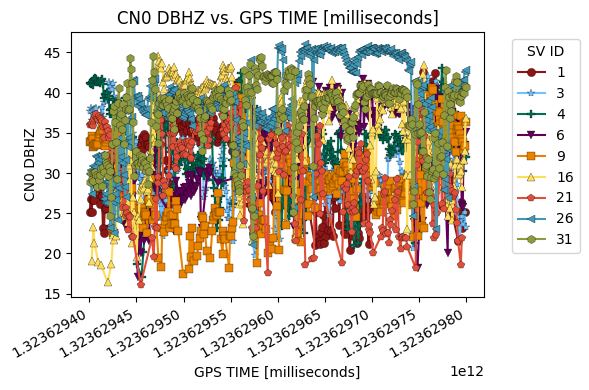

In [10]:
fig = plt.figure(figsize=(6, 4))
glp.plot_metric(android_gps_l1, "gps_millis", "cn0_dbhz", groupby="sv_id", fig=fig)
plt.show()

#### 5. Download the satellite data
In homework 1, you used the *precise* ephemeris, which are post-processed. However, in real-time, you only have access to the *broadcast* ephemeris made available in the satellite navigation message or retreivable from cellular towers via Assisted-GPS (A-GPS) services.

For this homework, we are accessing the broadcast ephemeris. This comes in a Receiver Independent Exchange (RINEX) format, maintained by the International GNSS Service (IGS) that you may recall from homework 1. Let's download the broadcast ephemeris and inspect it.

In [11]:
rinex_nav_paths = glp.load_ephemeris(
    "rinex_nav",
    android_gps_l1["gps_millis"],
    constellations=["gps"],
    download_directory=DEFAULT_EPHEM_PATH,
    verbose=True,
)
rinex_nav = glp.RinexNav(rinex_nav_paths, verbose=True)

ephemeris dates needed: [datetime.date(2021, 12, 15)]
using previously downloaded file:
 /content/drive/MyDrive/AA 272 - GPS Class/HW3/data/rinex/nav/brdc3490.21n
using previously downloaded file:
 /content/drive/MyDrive/AA 272 - GPS Class/HW3/data/rinex/nav/brdc3490.21n


Contents of rinex_nav:
Index(['sv_id', 'SVclockBias', 'SVclockDrift', 'SVclockDriftRate', 'IODE',
       'C_rs', 'deltaN', 'M_0', 'C_uc', 'e', 'C_us', 'sqrtA', 't_oe', 'C_ic',
       'Omega_0', 'C_is', 'i_0', 'C_rc', 'omega', 'OmegaDot', 'IDOT',
       'CodesL2', 'gps_week', 'L2Pflag', 'SVacc', 'health', 'TGD', 'IODC',
       'TransTime', 'FitIntvl', 'leap_seconds', 'source', 't_oc', 'gps_millis',
       'gnss_sv_id', 'gnss_id'],
      dtype='object')


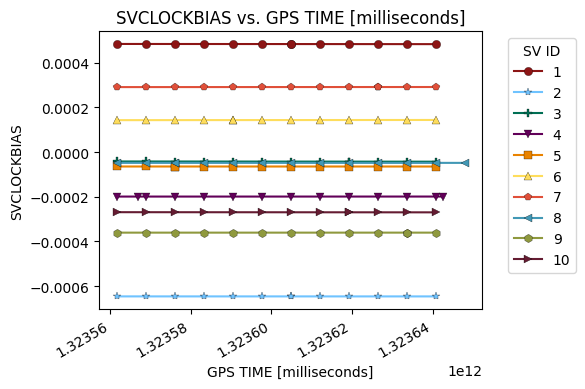

In [12]:
# Print columns and plot the broadcasted clock bias
print("Contents of rinex_nav:")
print(rinex_nav.pandas_df().columns)

fig = plt.figure(figsize=(6, 4))
glp.plot_metric(
    rinex_nav.where("sv_id", 10, "leq"), "gps_millis", "SVclockBias", groupby="sv_id", fig=fig
)
plt.show()

Now that we have both the receiver and satellite data, we are ready to start the problem!

### 1.1 Kepler's Equation with Newton-Raphson [4 points]

In lecture 5, we discussed that we can compute the eccentric anomaly $E$ for the satellite orbit through Kepler's Equation if we have the orbit's mean anomaly $M$ and its eccentricity $e$.
$$
M = E - e \sin E
$$
However, because Kepler's Equation has no closed-form solution, we need to solve for the eccentric anomaly $E$ iteratively. How would you use Newton-Raphson to iteratively solve for $E$ (given $M$ and $e$)? Write your answer in a clear, step-by-step approach. Ensure you include a clear mathematical expression for the iterative update step, which corrects your previous guess of the eccentric anomaly. For your initial guess of the eccentric anomaly, $E_0$, choose $M$.

**Hint:** Besides lecture 5, the introduction of these [course notes](https://web.mit.edu/10.001/Web/Course_Notes/NLAE/node6.html) might be helpful to reference when structuring the Newton-Raphson problem and algorithm.

***ANSWER***

The Newton-Raphson method is defined with the formula below.

$$ x_{n+1} = x_n + \frac{f(x)}{\frac{d}{dx}f(x)}$$
But with Kepler's equation,  the function becomes $f(E) = E - e\ sin \ E - M = 0$.

$$ E_{n+1} = E_n - \frac{f(E)}{\frac{d}{dE}f(E)} = E_n - \frac{E - e \ sin\ E - M}{1-e \ cos\ E}$$

In [13]:
def newton_raphson_for_eccentric_anomaly(mean_anomaly, eccentricity, tolerance, max_iter):
  """
  Compute the eccentric anomaly from the mean anomaly using Newton-Raphson for single values
  """

  ecc_anomaly = mean_anomaly  # Initial guess
  f = lambda E: E - eccentricity * np.sin(E) - mean_anomaly
  f_prime = lambda E: 1 - eccentricity * np.cos(E)

  for i in range(max_iter):
    ecc_anomaly = ecc_anomaly - f(ecc_anomaly) / f_prime(ecc_anomaly)

    # if isinstance(ecc_anomaly, list):
    #   if all(f(ecc))
    if np.all(abs(f(ecc_anomaly))) < tolerance:
      break



  return ecc_anomaly


# *** DO NOT MODIFY THE CODE BELOW ***
ecc_anomaly = newton_raphson_for_eccentric_anomaly(0.1, 0.2, 1e-3, 10)
# ecc_anomaly = newton_raphson_for_eccentric_anomaly(np.array([0.1]*2), np.array([0.2]*2), 1e-3, 10)
print("P1.1")
print("Ecc anomaly:", ecc_anomaly)

P1.1
Ecc anomaly: 0.12491884154998828


We provide a function that computes the eccentric anomaly from ephemeris parameters, using the function that you just implemented.

In [14]:
def _compute_eccentric_anomaly(gps_week, gps_tow, ephem, config, tol=1e-5, max_iter=10):
    """Compute the eccentric anomaly from ephemeris parameters.

    This function extracts relevant parameters from the broadcast navigation
    ephemerides and then solves the equation `f(E) = M - E + e * sin(E) = 0`
    using the Newton-Raphson method.

    In the above equation `M` is the corrected mean anomaly, `e` is the
    orbit eccentricity and `E` is the eccentric anomaly, which is unknown.

    Parameters
    ----------
    gps_week : int
        Week of GPS calendar corresponding to time of clock.
    gps_tow : np.ndarray
        GPS time of the week at which positions are required [s].
    ephem : gnss_lib_py.parsers.navdata.NavData
        NavData instance containing ephemeris parameters of satellites
        for which states are required.
    tol : float
        Tolerance for convergence of the Newton-Raphson.
    max_iter : int
        Maximum number of iterations for Newton-Raphson.

    Returns
    -------
    ecc_anom : np.ndarray
        Eccentric Anomaly of GNSS satellite orbits.

    """
    # Extract required parameters from ephemeris and GPS constants
    delta_n = ephem["deltaN"]
    mean_anom_0 = ephem["M_0"]
    sqrt_sma = ephem["sqrtA"]  # sqrt of semi-major axis
    sqrt_mu_a = np.sqrt(consts.MU_EARTH) * sqrt_sma**-3  # mean angular motion

    if config["use_eccentricity"]:
        ecc = ephem["e"]  # eccentricity
    else:
        ecc = 0.0 * ephem["e"]  # multiply by ephem entry to match the vector size

    gpsweek_diff = (np.mod(gps_week, 1024) - np.mod(ephem["gps_week"], 1024)) * consts.WEEKSEC
    delta_t = gps_tow - ephem["t_oe"] + gpsweek_diff

    # Calculate the mean anomaly with corrections
    if config["use_secular_corrections"]:
        mean_anom_corr = delta_n * delta_t
    else:
        mean_anom_corr = 0.0 * delta_n

    mean_anom = mean_anom_0 + (sqrt_mu_a * delta_t) + mean_anom_corr

    # Below we iteratively compute Eccentric Anomaly
    ecc_anom = newton_raphson_for_eccentric_anomaly(mean_anom, ecc, tol, max_iter)
    delta_ecc_anom = mean_anom - ecc_anom + ecc * np.sin(ecc_anom)

    if np.any(delta_ecc_anom > tol):  # pragma: no cover
        raise RuntimeWarning(
            "Eccentric Anomaly may not have converged"
            + f"after {max_iter} steps. : dE = {delta_ecc_anom}"
        )

    return ecc_anom

### 1.2 Satellite Clock Bias [4 points]

We also have to compute the satellite's clock bias term, corresponing to $B^{(k)}$ in our pseudorange equation. Refer to the most recent [GPS Interface Specification (IS)](https://www.navcen.uscg.gov/gps-technical-references) under GPS Space Segment/Navigation User Interfaces, and refer to the section on SV Clock Correction. You will notice the clock bias expression has four additive terms, one of which is a relativistic correction term. In addition to these terms, there is an additional fifth correction called the group delay term ($t_{GD}$, labeled in the code as `TGD`), that we already included for you.

**Hints:**

a. Your clock bias computation from following the GPS IS will give you clock corrections in seconds, but we already provide the code to convert to meters.

b. The GPS IS has a table that defines all clock and ephemeris parameters and their corresponding symbol representation used by the IS.

c. Notice that we want to use the time offset to account for the clock drift.

d. For the relativistic term, all the terms are multiplied together; there is no exponentiation. The formatting in the GPS IS is just a bit mis-formatted.

***ANSWER***

The SV PRN Code phse code phase time offset (the `corr_polynomial` term) is given by the following function, where $a_{f0}$, $a_{f1}$, and $a_{f2}$ are the polynomial coefficients given by the `SVclockBias`, `SVclockDrift`, and `SVclockDriftRate` parameters in the config, nad the $t-t_{oc}$ is the `t_offset` parameter in the function:
$$ \Delta t_{sv} = a_{f0} + a_{f1} (t - t_{oc}) + a_{f2} (t- t_{oc})^2 + \Delta t_r$$

For the relativistic clock correction term, the following formula is used, with the square root of the semi_major axis given by $\sqrt{A}$ and `sqrt_sma` in the code, the eccentric anomaly $E_k$ being `ecc` in the code, and a constant $F = -4.442807633 \times 10^{-10} \left[\frac{sec}{\sqrt{meter}}\right]$:

$$\Delta t_r = F e^{\sqrt{A}}\ sin\ E_k$$

<!-- #[Provide the formula for the satellite clock bias correction and implement the function below] -->

In [21]:
def clock_bias_calculation(config, ephem, t_offset, ecc, sqrt_sma, ecc_anom):
    """
    Compute the clock bias correction from the ephemeris parameters.

    Parameters
    ----------
    config : dict
        Configuration dictionary.
    ephem : gnss_lib_py.parsers.navdata.NavData
        Ephemeris parameters.
    t_offset : float
        Time offset in seconds.
    ecc : float
        Eccentricity.
    sqrt_sma : float
        Square root of semi-major axis.
    ecc_anom : float
        Eccentric anomaly.

    Returns
    -------
    corr_polynomial : float
        Polynomial clock perturbation terms [m].
    corr_relativistic : float
        Relativistic clock correction terms [m].
    """
    # *****************************************************************
    # Clock Bias Calculation ******************************************
    # *****************************************************************

    # print(ephem)

    mu = 3.986005e14  # m3/s2
    c = 2.99792458e8  # m/s
    F = -2*np.sqrt(mu) / (c*c)


    if config["use_clock_drift_and_rate"]:
      # Calculate clock corrections from the polynomial corrections in
      # broadcast message
      a_f0 = ephem["SVclockBias"]
      a_f1 = ephem["SVclockDrift"]
      a_f2 = ephem["SVclockDriftRate"]

      corr_polynomial =  a_f0 + a_f1 * t_offset + a_f2 * t_offset**2 # TODO: Add your code here
    else:
      corr_polynomial = ephem["SVclockBias"]

    if config["use_clock_relativistic_correction"]:
      # Calcualte the relativistic clock correction
      corr_relativistic = F * ecc * sqrt_sma * np.sin(ecc_anom)
    else:
      corr_relativistic = 0.0 * ecc_anom

    # *****************************************************************
    # *****************************************************************
    return corr_polynomial, corr_relativistic


# *** DO NOT MODIFY THE CODE BELOW ***
config_tmp = {
    "use_clock_drift_and_rate": True,
    "use_clock_relativistic_correction": True,
}
np.random.seed(0)
rnd = np.random.random(3)
ephem_tmp = {"SVclockBias": rnd, "SVclockDrift": rnd, "SVclockDriftRate": rnd}
corr_p, corr_r = clock_bias_calculation(config_tmp, ephem_tmp, rnd, rnd, rnd, rnd)
print("P1.2")
print("corr_p:", corr_p)
print("corr_r:", corr_r)

P1.2
corr_p: [1.01531034 1.59250157 1.18508528]
corr_r: [-6.98083541e-11 -1.49020079e-10 -9.15111026e-11]


Below we provide a function that computes the satellite clock delay, using the function that you just implemented.

In [22]:
# @title
def _estimate_sv_clock_corr(gps_millis, ephem, config):
    """

    Calculate the modeled satellite clock delay

    Please refer to section 20.3.3.3.1.8 through 20.3.3.3.3.1 in the GPS
    interface specification document (IS-GPS-200N)

    Parameters
    ---------
    gps_millis : int
        Time at which measurements are needed, measured in milliseconds
        since start of GPS epoch [ms].
    ephem : gnss_lib_py.parsers.navdata.NavData
        Satellite ephemeris parameters for measurement SVs.
    config : dictionary
        Parameters to turn corrections off or on

    Returns
    -------
    clock_corr : np.ndarray
        Satellite clock corrections containing all terms [m].
    corr_polynomial : np.ndarray
        Polynomial clock perturbation terms [m].
    clock_relativistic : np.ndarray
        Relativistic clock correction terms [m].
    """
    # Extract required GPS constants
    ecc = ephem["e"]  # eccentricity
    sqrt_sma = ephem["sqrtA"]  # sqrt of semi-major axis
    gps_week, gps_tow = glp.gps_millis_to_tow(gps_millis)

    # Compute Eccentric Anomaly
    # This uses your Newton-Raphson Code above
    ecc_anom = _compute_eccentric_anomaly(gps_week, gps_tow, ephem, config)

    # Determine pseudorange corrections due to satellite clock corrections.
    # Calculate time offset from satellite reference time
    t_offset = gps_tow - ephem["t_oc"]
    if np.abs(t_offset).any() > 302400:  # pragma: no cover
        t_offset = t_offset - np.sign(t_offset) * 604800

    corr_polynomial, corr_relativistic = clock_bias_calculation(
        config, ephem, t_offset, ecc, sqrt_sma, ecc_anom
    )

    # OUTPUT PROCESSING

    # Calculate the total clock correction including the Tgd term
    if "TGD" in ephem.rows:
        clk_corr = corr_polynomial - ephem["TGD"] + corr_relativistic
    elif "BGDe5b" in ephem.rows:
        # Assuming single frequency measurements are used and that
        # E1 or E5b frequencies are used for state estimation
        clk_corr = corr_polynomial - ephem["BGDe5b"] + corr_relativistic
    elif "TGD1" in ephem.rows:
        clk_corr = corr_polynomial - ephem["TGD1"] + corr_relativistic
    # Convert values to equivalent meters from seconds
    clk_corr = np.array(consts.C * clk_corr, ndmin=1)
    corr_polynomial = np.array(consts.C * corr_polynomial, ndmin=1)
    corr_relativistic = np.array(consts.C * corr_relativistic, ndmin=1)

    return clk_corr, corr_polynomial, corr_relativistic

### 1.3 Ephemeris Errors [2 points]

After implementing a solver for Kepler's equation and a function to compute the clock corrections, we are ready to take the orbital parameters in the ephemeris data and compute the satellite states. The term *states* refers to the combination of position, velocity, and clock bias in the ECEF frame. The function below implements the algorithm introduced in lecture 5, which is common in GPS receivers. Note that it calls the functions that you just implemented.

In [23]:
# @title
def orbit_params_to_sv_states(gps_millis, ephem_orbit_params, config):
    """Compute position and velocities for all satellites in ephemeris file
    given time of clock.

    `ephem` contains broadcast ephemeris parameters.

    Must contain the following rows (description in [1]_):
    * :code:`gnss_id`
    * :code:`sv_id`
    * :code:`gps_week`/`beidou_week`
    * :code:`t_oe`
    * :code:`e`
    * :code:`omega`
    * :code:`Omega_0`
    * :code:`OmegaDot`
    * :code:`sqrtA`
    * :code:`deltaN`
    * :code:`IDOT`
    * :code:`i_0`
    * :code:`C_is`
    * :code:`C_ic`
    * :code:`C_rs`
    * :code:`C_rc`
    * :code:`C_uc`
    * :code:`C_us`

    Parameters
    ----------
    gps_millis : int
        Time at which measurements are needed, measured in milliseconds
        since start of GPS epoch [ms].
    ephem : gnss_lib_py.parsers.navdata.NavData
        NavData instance containing ephemeris parameters of satellites
        for which states are required.
    config : dictionary
        Parameters to turn corrections off or on

    Returns
    -------
    sv_posvel : gnss_lib_py.parsers.navdata.NavData
        NavData containing satellite positions, velocities, corresponding
        time with GNSS ID and SV number.

    Notes
    -----
    Please refer to sections 20.3.3.4.1 through 20.3.3.4.3.2 in the GPS
    interface specification document (IS-GPS-200N)

    """

    # Convert time from GPS millis to TOW
    gps_week, gps_tow = glp.gps_millis_to_tow(gps_millis)

    # Initialize the output data
    sv_posvel = glp.NavData()
    sv_posvel["gnss_id"] = ephem_orbit_params["gnss_id"]
    sv_posvel["sv_id"] = ephem_orbit_params["sv_id"]
    sv_posvel["gps_millis"] = gps_millis

    # Extract parameters from the ephemeris
    # Harmonic correction terms
    c_is = ephem_orbit_params["C_is"]
    c_ic = ephem_orbit_params["C_ic"]
    c_rs = ephem_orbit_params["C_rs"]
    c_rc = ephem_orbit_params["C_rc"]
    c_uc = ephem_orbit_params["C_uc"]
    c_us = ephem_orbit_params["C_us"]
    # Secular mean motion correction term
    delta_n = ephem_orbit_params["deltaN"]

    # Base orbital elements
    omega = ephem_orbit_params["omega"]  # argument of perigee
    omega_0 = ephem_orbit_params["Omega_0"]  # longitude of ascending node
    sqrt_sma = ephem_orbit_params["sqrtA"]  # sqrt of semi-major axis

    if config["use_eccentricity"]:
        ecc = ephem_orbit_params["e"]  # eccentricity
    else:
        ecc = 0.0 * ephem_orbit_params["e"]

    ############################################
    ######  Lines added for SV Position  #######
    ############################################

    # STEP 1: Compute semimajor axis (A)
    sma = sqrt_sma**2  # semi-major axis

    # STEP 2: Compute mean motion (n_0)
    sqrt_mu_a = np.sqrt(consts.MU_EARTH) * sqrt_sma**-3  # mean angular motion

    # STEP 3: Compute time from ephemeris reference epoch
    # This is the asterisk at the bottom of Table 20-IV. Broadcast Navigation
    # User Equations (sheet 1 of 4) in IS-GPS-200N
    gpsweek_diff = (
        np.mod(gps_week, 1024) - np.mod(ephem_orbit_params["gps_week"], 1024)
    ) * consts.WEEKSEC
    # This is the calculation at step 3 in the table
    delta_t = gps_tow - ephem_orbit_params["t_oe"] + gpsweek_diff

    # STEPS 4-8: From corrected mean motion to final value of eccentric anomaly
    # Calculate the mean anomaly with corrections
    ecc_anom = _compute_eccentric_anomaly(gps_week, gps_tow, ephem_orbit_params, config)

    # STEP 9: Compute the True Anomaly in a way that tells you which quadrant
    # you are in.
    cos_e = np.cos(ecc_anom)
    sin_e = np.sin(ecc_anom)
    e_cos_e = 1 - ecc * cos_e

    # Calculate the true anomaly from the eccentric anomaly
    sin_nu = np.sqrt(1 - ecc**2) * (sin_e / e_cos_e)
    cos_nu = (cos_e - ecc) / e_cos_e
    nu_rad = np.arctan2(sin_nu, cos_nu)

    # Sheet 2 of 4 of Table 20-IV in IS-GPS-200N
    # STEPS 10 & 11a: Calculate the argument of latitude iteratively
    phi_0 = nu_rad + omega
    phi = phi_0

    if config["use_iterate_argument_of_latitude"]:
        n_iter_phi = 5
    else:
        n_iter_phi = 1

    for _ in range(n_iter_phi):
        if config["use_harmonic_corrections"]:
            cos_to_phi = np.cos(2.0 * phi)
            sin_to_phi = np.sin(2.0 * phi)
        else:
            cos_to_phi = 0.0 * phi
            sin_to_phi = 0.0 * phi
        phi_corr = c_uc * cos_to_phi + c_us * sin_to_phi
        # note that phi_corr is labelled as delta u_k in IS-GPS-200N
        phi = phi_0 + phi_corr

    # STEPS 11b & 13: Calculate orbital radius with correction
    r_corr = c_rc * cos_to_phi + c_rs * sin_to_phi
    orb_radius = sma * e_cos_e + r_corr

    # STEPS 11c & 14: Calculate the inclination with correction
    i_corr = c_ic * cos_to_phi + c_is * sin_to_phi + ephem_orbit_params["IDOT"] * delta_t
    incl = ephem_orbit_params["i_0"] + i_corr

    # STEP 15: Find the position in the orbital plane (PQW frame)
    x_plane = orb_radius * np.cos(phi)
    y_plane = orb_radius * np.sin(phi)

    # STEP 16: Calculate the longitude of ascending node with correction
    if config["use_secular_corrections"]:
        omega_corr = ephem_orbit_params["OmegaDot"] * delta_t
    else:
        omega_corr = 0.0 * ephem_orbit_params["OmegaDot"]

    # Also correct for the rotation since the beginning of the GPS week for
    # which the Omega0 is defined.  Correct for GPS week rollovers.
    omega = omega_0 - (consts.OMEGA_E_DOT * (gps_tow + gpsweek_diff)) + omega_corr

    # STEP 17: Find satellite position in ECEF coordinates
    cos_omega = np.cos(omega)
    sin_omega = np.sin(omega)
    cos_i = np.cos(incl)
    sin_i = np.sin(incl)

    sv_posvel["x_sv_m"] = x_plane * cos_omega - y_plane * cos_i * sin_omega
    sv_posvel["y_sv_m"] = x_plane * sin_omega + y_plane * cos_i * cos_omega
    sv_posvel["z_sv_m"] = y_plane * sin_i

    ############################################
    ######  Lines added for SV Velocity  #######
    ############################################

    # STEP 1: Eccentric Anomaly Rate
    delta_e = (sqrt_mu_a + delta_n) / e_cos_e

    # STEP 2: True Anomaly Rate
    delta_nu = np.sqrt(1 - ecc**2) * delta_e / e_cos_e

    # STEP 3: Correcting Inclination Angle Rate
    delta_i = ephem_orbit_params["IDOT"] + 2 * (c_is * cos_to_phi - c_ic * sin_to_phi) * delta_nu

    # STEP 4: Corrected Argument of Latitude Rate
    # Note again that IS-GPS-200N uses u_k for this.
    delta_u = (1 + 2 * (c_us * cos_to_phi - c_uc * sin_to_phi)) * delta_nu

    # STEP 5: Corrected Radius Rate
    delta_r = (sma * ecc * delta_e * sin_e) + 2 * (c_rs * cos_to_phi - c_rc * sin_to_phi) * delta_nu

    # STEP 6: Corrected Longitude of Ascending Node Rate
    omega_dot = ephem_orbit_params["OmegaDot"] - consts.OMEGA_E_DOT

    # STEPS 7 - 8: In plane x and y velocity (PQW)
    dxp = delta_r * np.cos(phi) - orb_radius * np.sin(phi) * delta_u
    dyp = delta_r * np.sin(phi) + orb_radius * np.cos(phi) * delta_u

    # STEPS 9 - 11: ECEF x, y, and z velocity
    sv_posvel["vx_sv_mps"] = (
        dxp * cos_omega
        - dyp * cos_i * sin_omega
        + y_plane * sin_omega * sin_i * delta_i
        - (x_plane * sin_omega + y_plane * cos_i * cos_omega) * omega_dot
    )

    sv_posvel["vy_sv_mps"] = (
        dxp * sin_omega
        + dyp * cos_i * cos_omega
        - y_plane * sin_i * cos_omega * delta_i
        + (x_plane * cos_omega - (y_plane * cos_i * sin_omega)) * omega_dot
    )

    sv_posvel["vz_sv_mps"] = dyp * sin_i + y_plane * cos_i * delta_i

    ############################################
    #####  Lines added for SV Clock Bias  ######
    ############################################

    # Estimate SV clock corrections, including polynomial and relativistic
    # clock corrections
    clock_corr, _, _ = _estimate_sv_clock_corr(gps_millis, ephem_orbit_params, config)

    sv_posvel["b_sv_m"] = clock_corr

    return sv_posvel

Now we will loop through the receiver data and run the functions above. Note that the implemented functions allow accounting for different effects, such as whether to use the relativistic clock corrections. Below we introduce a configuration dictionary and helper functions so that you can more easily separate out each effect.

In [24]:
# @title
# Config. True = use it. False = don't use it

config = {
    "use_eccentricity": True,
    "use_clock_drift_and_rate": True,
    "use_clock_relativistic_correction": True,
    "use_secular_corrections": False,
    "use_harmonic_corrections": False,
    "use_iterate_argument_of_latitude": True,
    "use_WLS_rx_to_tx_time": True,
}


def config_str_to_dict(config_str):
    """Converts a string of config to a dictionary of config."""
    config = {
        "use_eccentricity": config_str[0] == "T",
        "use_clock_drift_and_rate": config_str[1] == "T",
        "use_clock_relativistic_correction": config_str[2] == "T",
        "use_secular_corrections": config_str[3] == "T",
        "use_harmonic_corrections": config_str[4] == "T",
        "use_iterate_argument_of_latitude": config_str[5] == "T",
        "use_WLS_rx_to_tx_time": config_str[6] == "T",
    }
    return config


def config_dict_to_str(config):
    """Converts a dictionary of config to a string of config."""
    config_str = "".join(["T" if use else "F" for use in config.values()])
    return config_str


# Converts the dictionary above into a string
print(config_dict_to_str(config))

TTTFFTT


In [25]:
# @title
sv_err_cols = ["x_err_m", "y_err_m", "z_err_m", "vx_err_mps", "vy_err_mps", "vz_err_mps", "b_err_m"]


def run_problem_1(config):
    sv_state_errors = glp.NavData()
    total_times = len(np.unique(android_gps_l1["gps_millis"]))

    # We will loop through the time stamps (aka gps millis) in the data set
    for gps_milli, dt, measure_frame in tqdm(
        glp.loop_time(android_gps_l1, "gps_millis"), total=total_times
    ):
        # Sort by satellite to line up with ephemeris and allow vectorization
        glp.sort(measure_frame, "sv_id", inplace=True)
        # Extract the ephemeris with the closest time to this gps millisecond
        # Usually, it is the same for most of the dataset, but we use this for
        # simplicity
        ephem = get_closest_rinex_data(gps_milli, rinex_nav, constellations=["gps"])
        # Extract the satellites that are currently tracked
        ephem = ephem.where("sv_id", measure_frame["sv_id"], "eq")

        # Without WLS, the best that you can do is guess the rough time between
        # receiver time (rx) and transmit time (tx) as ~70ms. This is quite coarse.
        sv_posvel = orbit_params_to_sv_states(gps_milli - 1000.0 * consts.T_TRANS, ephem, config)

        if config["use_WLS_rx_to_tx_time"]:
            # Extract the receiver position from WLS in the dataset for more
            # precise ranging. In a real system, you compute the user position and
            # refine your satellite estimates in real time.
            rx_ecef = measure_frame[rx_pos_cols, 0]
            rx_ecef = np.reshape(rx_ecef, [3, 1])

            del_pos, true_range = _find_delxyz_range(sv_posvel, rx_ecef)
            t_corr = true_range / consts.C
            # Find satellite locations at (a more accurate) time of transmission
            sv_posvel = orbit_params_to_sv_states(gps_milli - 1000.0 * t_corr, ephem, config)

        # The rest of the data below is used to calculate the error and join it
        # together across time.
        sv_err_tmp = glp.NavData()
        for row in sv_info_cols:
            sv_err_tmp[row] = sv_posvel[row]
        for row_idx, row in enumerate(sv_pos_cols):
            err_row = sv_err_cols[row_idx]

            split_sv_row = row.split("_")
            split_err_row = err_row.split("_")
            assert (
                split_sv_row[0] == split_err_row[0] and split_err_row[2] == split_sv_row[2]
            ), f"Quantities in row names {row} and {err_row} do not match"

            sv_err_tmp[err_row] = sv_posvel[row] - measure_frame[row]
        if len(sv_state_errors) == 0:
            sv_state_errors = sv_err_tmp
        else:
            sv_state_errors = glp.concat(sv_state_errors, sv_err_tmp, axis=1)

    return sv_state_errors

In [26]:
config = {
    "use_eccentricity": True,
    "use_clock_drift_and_rate": True,
    "use_clock_relativistic_correction": True,
    "use_secular_corrections": False,
    "use_harmonic_corrections": False,
    "use_iterate_argument_of_latitude": True,
    "use_WLS_rx_to_tx_time": True,
}

sv_state_errors = run_problem_1(config)

100%|██████████| 400/400 [00:25<00:00, 15.60it/s]


We use GNSS Lib Py to generate some of the plots you will need for the homework to avoid too much work on your end. The `T` and `F` characters at the start tell you which corrections were turned on or off.

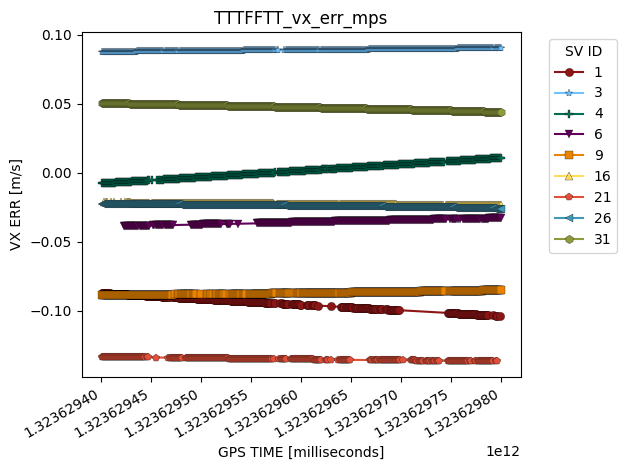

In [27]:
# @title
row = "vx_err_mps"
fig = plt.figure()
glp.plot_metric(
    sv_state_errors,
    "gps_millis",
    row,
    groupby="sv_id",
    title=config_dict_to_str(config) + "_" + row,
    fig=fig,
)
plt.show()

Set all the toggles to `True`. This will match the algorithm in the GPS Interface Specification. We will compare the satellite positions, velocities, and clock bias that Google computed for the 2022 Google Smartphone Decimeter Challenge. Please include your plot for the error in the x ECEF position `x_err_m` and the clock bias `b_err_m`.

**Side note**: Google is likely doing a bit more processing than we are, so it will not line up exactly, but the errors should be close to zero.

***ANSWER***

In [28]:
sv_state_errors = run_problem_1(config_str_to_dict("TTTTTTT"))

# *** DO NOT MODIFY THE CODE BELOW ***
errors = [float(f"{x:.3g}") for x in sv_state_errors.array[:, 0]] if sv_state_errors else []
print("P1.3")
print("Errors:", errors)

100%|██████████| 400/400 [00:26<00:00, 15.28it/s]

P1.3
Errors: [1320000000000.0, 1.0, 0.0, -0.0126, -0.0003, 0.0987, 0.000674, 0.000254, 9.34e-05, 1.53e-06]


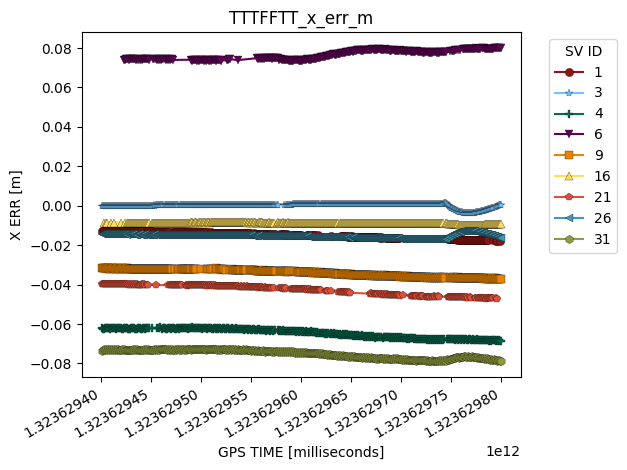

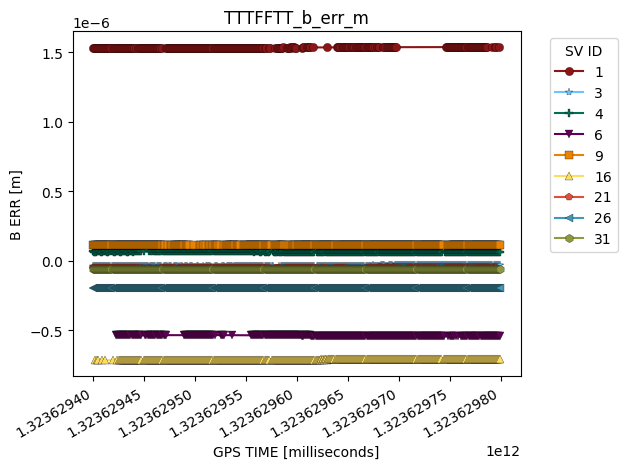

In [29]:
for row in ("x_err_m", "b_err_m"):

    if sv_state_errors is None:
        continue

    fig = plt.figure()
    glp.plot_metric(
        sv_state_errors,
        "gps_millis",
        row,
        groupby="sv_id",
        title=config_dict_to_str(config) + "_" + row,
        fig=fig,
    )
    plt.show()

In [30]:
sv_state_errors.rows

['gps_millis',
 'sv_id',
 'gnss_id',
 'x_err_m',
 'y_err_m',
 'z_err_m',
 'vx_err_mps',
 'vy_err_mps',
 'vz_err_mps',
 'b_err_m']

### 1.4 Error Statistic [1 point]

We will convert this multi-satellite time series into a single number to make comparison easier. For each variable (e.g., the error in the satellite x ECEF position), we want to take the mean of the absolute value of the error across the entire dataset (i.e., all time and all satellites). Fill in the function for `calculate_error_statistic`.

**Hint**: In the function, we will pass in the variable across the entire dataset. For example, this could be the satellite x ECEF position error.

**Hint**: The function should be short (roughly 1 line of code).

***ANSWER***

[Complete the function below]

In [31]:
def calculate_error_statistic(variable_data):
    """
    Calculate the error statistic from one row of data.
    """
    error_statistic = np.mean(np.abs(variable_data)) # TODO: Add your code here
    return error_statistic

# *** DO NOT MODIFY THE CODE BELOW ***
np.random.seed(0)
error_statistic = calculate_error_statistic(np.random.random(5))
print("P1.4")
print("Error statistic:", error_statistic)

P1.4
Error statistic: 0.567060845741438


In [32]:
stats = []
print("Error Statistics:")
for row in sv_err_cols:
    stat = calculate_error_statistic(sv_state_errors[row])

    # .4g is scientific notation with 4 significant figures, try .2f for 2 decimal places
    # \t is a tab character
    print(f"  {row}\t {stat:.4g}")
    stats.append(stat)

Error Statistics:
  x_err_m	 0.03674
  y_err_m	 0.03443
  z_err_m	 0.06434
  vx_err_mps	 0.0003134
  vy_err_mps	 0.0004887
  vz_err_mps	 0.000292
  b_err_m	 3.355e-07


### 1.5 Ablation Study [8 points]

An ablation study is a process of systematically removing parts of a model or algorithm to measure how those removals affect its performance.
By seeing how much performance drops when a specific part is removed ("ablated"), you can determine its importance to the overall system.

Ablate *one variable* at a time. In the configuration, only *one* variable should be false, and the rest should be marked true. Record the error for each variable. This table should include the errors for all seven variables $(x, y, z, v_x, v_y, v_z, B)$. The table should span the baseline algorithm above and each ablation. Please include headers for both rows and columns in the table.

**Hint**: Make sure to include: (1) nothing ablated, (2) only eccentricity ablated, (3) only clock bias and drift ablated, (4) only relativistic clock effects ablated, (5) only secular corrections ablated, (6) only harmonic corrections ablated, (7) only iterative corrections ablated, and (8) only WLS timing corrections ablated.

Below we provide some boilerplate code to run multiple configurations. We create a cache dictionary to avoid recomputing the same data. Image that you start with the config `TFFT` and then you want to run `TFFT` and `TTTT`. The cache will store the data from the first run and then only compute the new data. This can be very useful in your final projects to avoid recomputing the same data over and over. If you make changes to the code and need to recompute the results, just run the cell below to clear the cache.

***ANSWER***

[Complete the list of configurations below and run the code]

In [33]:
# # Create a cache for the results to avoid recomputing
# # Run this cell to clear the cache
# config_cache = {}
config_cache = {'TTTTTTT': {'x_err_m': np.float64(0.03673860180272302),
  'y_err_m': np.float64(0.034428655027538294),
  'z_err_m': np.float64(0.06433795095284517),
  'vx_err_mps': np.float64(0.0003133824489911577),
  'vy_err_mps': np.float64(0.0004887363005841622),
  'vz_err_mps': np.float64(0.00029195797131111045),
  'b_err_m': np.float64(3.356171890736687e-07)},
 'FTTTTTT': {'x_err_m': np.float64(190997.42091955282),
  'y_err_m': np.float64(181165.62495882247),
  'z_err_m': np.float64(204691.6673765564),
  'vx_err_mps': np.float64(15.56155602880255),
  'vy_err_mps': np.float64(9.915872193300112),
  'vz_err_mps': np.float64(18.120202396100407),
  'b_err_m': np.float64(0.01551215623621625)},
 'TFTTTTT': {'x_err_m': np.float64(0.03673860180272302),
  'y_err_m': np.float64(0.034428655027538294),
  'z_err_m': np.float64(0.06433795095284517),
  'vx_err_mps': np.float64(0.0003133824489911577),
  'vy_err_mps': np.float64(0.0004887363005841622),
  'vz_err_mps': np.float64(0.00029195797131111045),
  'b_err_m': np.float64(4.924987385233733)},
 'TTFTTTT': {'x_err_m': np.float64(0.03673860180272302),
  'y_err_m': np.float64(0.034428655027538294),
  'z_err_m': np.float64(0.06433795095284517),
  'vx_err_mps': np.float64(0.0003133824489911577),
  'vy_err_mps': np.float64(0.0004887363005841622),
  'vz_err_mps': np.float64(0.00029195797131111045),
  'b_err_m': np.float64(4.373337623474667)},
 'TTTFTTT': {'x_err_m': np.float64(215.47391841179635),
  'y_err_m': np.float64(149.19816626940482),
  'z_err_m': np.float64(198.3708492526965),
  'vx_err_mps': np.float64(0.026372424318372473),
  'vy_err_mps': np.float64(0.03743860977206459),
  'vz_err_mps': np.float64(0.028401709117255078),
  'b_err_m': np.float64(3.3030987069560406e-05)},
 'TTTTFTT': {'x_err_m': np.float64(105.083312539487),
  'y_err_m': np.float64(102.66758548604889),
  'z_err_m': np.float64(113.0825848080317),
  'vx_err_mps': np.float64(0.05107930310557273),
  'vy_err_mps': np.float64(0.04358242064236514),
  'vz_err_mps': np.float64(0.04773219542122112),
  'b_err_m': np.float64(3.3568681808523307e-07)},
 'TTTTTFT': {'x_err_m': np.float64(0.037513629702754334),
  'y_err_m': np.float64(0.03484812455807359),
  'z_err_m': np.float64(0.06425640787988736),
  'vx_err_mps': np.float64(0.00031341013643708653),
  'vy_err_mps': np.float64(0.0004886165281550634),
  'vz_err_mps': np.float64(0.00029170328774000113),
  'b_err_m': np.float64(3.356171890736687e-07)},
 'TTTTTTF': {'x_err_m': np.float64(8.618705946516345),
  'y_err_m': np.float64(5.883808369578093),
  'z_err_m': np.float64(13.096588676677499),
  'vx_err_mps': np.float64(0.0012150879847963641),
  'vy_err_mps': np.float64(0.0016559642399645558),
  'vz_err_mps': np.float64(0.0020123833765537695),
  'b_err_m': np.float64(9.864372448619281e-06)}}

In [34]:
# For reference, order matters
config = {
    "use_eccentricity": True,
    "use_clock_drift_and_rate": True,
    "use_clock_relativistic_correction": True,
    "use_secular_corrections": True,
    "use_harmonic_corrections": True,
    "use_iterate_argument_of_latitude": True,
    "use_WLS_rx_to_tx_time": True,
}

In [35]:
# Create your own config here
config_str_list = [
    "TTTTTTT",  # None
    "FTTTTTT",
    "TFTTTTT",
    "TTFTTTT",
    "TTTFTTT",
    "TTTTFTT",
    "TTTTTFT",
    "TTTTTTF"
]

In [36]:
# Save the results
all_errors = {}

# Run the problem for each set of config
for i, config_str in enumerate(config_str_list):

    print(f"\nConfig {i+1}/{len(config_str_list)}: {config_str}")
    if config_str in config_cache:
        # Load the errorsb
        errors = config_cache[config_str]
    else:
        # Compute errors
        config = config_str_to_dict(config_str)
        sv_state_errors = run_problem_1(config)

        # Print statistics
        errors = {}
        for row in sv_err_cols:
            stat = calculate_error_statistic(sv_state_errors[row])
            errors[row] = stat
            print(f"  {row}\t{stat:.4g}")

        # Save the errors
        config_cache[config_str] = errors

    # Save the errors
    all_errors[config_str] = errors


Config 1/8: TTTTTTT

Config 2/8: FTTTTTT

Config 3/8: TFTTTTT

Config 4/8: TTFTTTT

Config 5/8: TTTFTTT

Config 6/8: TTTTFTT

Config 7/8: TTTTTFT

Config 8/8: TTTTTTF


In [37]:
# *** DO NOT MODIFY THE CODE BELOW ***
print("P1.5")
lines = [[float(f"{x:.3g}") for x in y.values()] for y in all_errors.values()]
for l in lines:
    print(l)

P1.5
[0.0367, 0.0344, 0.0643, 0.000313, 0.000489, 0.000292, 3.36e-07]
[191000.0, 181000.0, 205000.0, 15.6, 9.92, 18.1, 0.0155]
[0.0367, 0.0344, 0.0643, 0.000313, 0.000489, 0.000292, 4.92]
[0.0367, 0.0344, 0.0643, 0.000313, 0.000489, 0.000292, 4.37]
[215.0, 149.0, 198.0, 0.0264, 0.0374, 0.0284, 3.3e-05]
[105.0, 103.0, 113.0, 0.0511, 0.0436, 0.0477, 3.36e-07]
[0.0375, 0.0348, 0.0643, 0.000313, 0.000489, 0.000292, 3.36e-07]
[8.62, 5.88, 13.1, 0.00122, 0.00166, 0.00201, 9.86e-06]


In [38]:
# Pandas is a great library for working with tables. NavData is inspired by it.
import pandas as pd

pretty_cols = {
    "x_err_m": "x [m]",
    "y_err_m": "y [m]",
    "z_err_m": "z [m]",
    "vx_err_mps": "vx [m/s]",
    "vy_err_mps": "vy [m/s]",
    "vz_err_mps": "vz [m/s]",
    "b_err_m": "b [m]",
}

pretty_rows = {
    "TTTTTTT": "Nothing ablated",
    "FTTTTTT": "No Eccentricity",
    "TFTTTTT": "No Clock Drift and Rate",
    "TTFTTTT": "No Relativistic Correction",
    "TTTFTTT": "No Secular Corrections",
    "TTTTFTT": "No Harmonic Corrections",
    "TTTTTFT": "No Iterate Argument of Latitude",
    "TTTTTTF": "No WLS Rx to Tx Time",
}

cols_dict = {}
errors_df = pd.DataFrame(all_errors).T
errors_df.columns = [pretty_cols[col] for col in errors_df.columns]  # Rename columns
errors_df.index = [pretty_rows[idx] for idx in errors_df.index]  # Rename rows
errors_df.map(lambda x: f"{x:.2g}")  # Format the numbers to 2 significant figures

,x [m],y [m],z [m],vx [m/s],vy [m/s],vz [m/s],b [m]
Nothing ablated,0.037,0.034,0.064,0.00031,0.00049,0.00029,3.4e-07
No Eccentricity,1.9e+05,1.8e+05,2e+05,16,9.9,18,0.016
No Clock Drift and Rate,0.037,0.034,0.064,0.00031,0.00049,0.00029,4.9
No Relativistic Correction,0.037,0.034,0.064,0.00031,0.00049,0.00029,4.4
No Secular Corrections,2.2e+02,1.5e+02,2e+02,0.026,0.037,0.028,3.3e-05
No Harmonic Corrections,1.1e+02,1e+02,1.1e+02,0.051,0.044,0.048,3.4e-07
No Iterate Argument of Latitude,0.038,0.035,0.064,0.00031,0.00049,0.00029,3.4e-07
No WLS Rx to Tx Time,8.6,5.9,13,0.0012,0.0017,0.002,9.9e-06


In [39]:
# @title
# Although it is not required for this homework, the following code shows how you can easily export tables to LaTeX, which can be useful for your final project.

print("\\begin{table}[H]\n\\centering\n\\scriptsize")
print(
    "\\caption{Ablation study for errors in satellite states in ECEF compared to calculations available from the GSDC data}"
)
print(errors_df.to_latex(float_format=lambda x: f"$\\num{{{x:.2g}}}$"))
print("\\end{table}")

\begin{table}[H]
\centering
\scriptsize
\caption{Ablation study for errors in satellite states in ECEF compared to calculations available from the GSDC data}
\begin{tabular}{lrrrrrrr}
\toprule
 & x [m] & y [m] & z [m] & vx [m/s] & vy [m/s] & vz [m/s] & b [m] \\
\midrule
Nothing ablated & $\num{0.037}$ & $\num{0.034}$ & $\num{0.064}$ & $\num{0.00031}$ & $\num{0.00049}$ & $\num{0.00029}$ & $\num{3.4e-07}$ \\
No Eccentricity & $\num{1.9e+05}$ & $\num{1.8e+05}$ & $\num{2e+05}$ & $\num{16}$ & $\num{9.9}$ & $\num{18}$ & $\num{0.016}$ \\
No Clock Drift and Rate & $\num{0.037}$ & $\num{0.034}$ & $\num{0.064}$ & $\num{0.00031}$ & $\num{0.00049}$ & $\num{0.00029}$ & $\num{4.9}$ \\
No Relativistic Correction & $\num{0.037}$ & $\num{0.034}$ & $\num{0.064}$ & $\num{0.00031}$ & $\num{0.00049}$ & $\num{0.00029}$ & $\num{4.4}$ \\
No Secular Corrections & $\num{2.2e+02}$ & $\num{1.5e+02}$ & $\num{2e+02}$ & $\num{0.026}$ & $\num{0.037}$ & $\num{0.028}$ & $\num{3.3e-05}$ \\
No Harmonic Corrections & $\nu

### 1.6 Error Plots [3 points]

Finally, let's visualize some of the errors from our ablation study.
Include the plots for the satellite $x$ ECEF position error for the following ablations:

- only eccentricity ablated

- only secular corrections ablated

- only harmonic corrections ablated

***ANSWER***

100%|██████████| 400/400 [00:29<00:00, 13.52it/s]


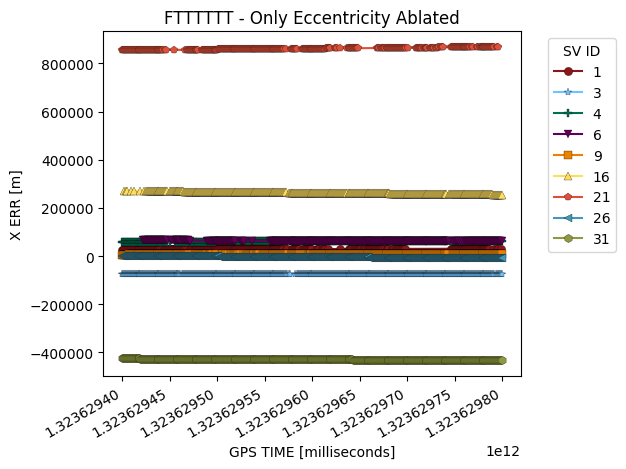

100%|██████████| 400/400 [00:32<00:00, 12.42it/s]


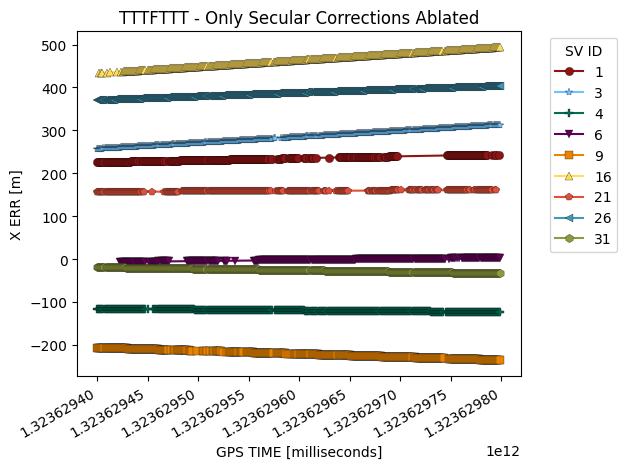

100%|██████████| 400/400 [00:35<00:00, 11.38it/s]


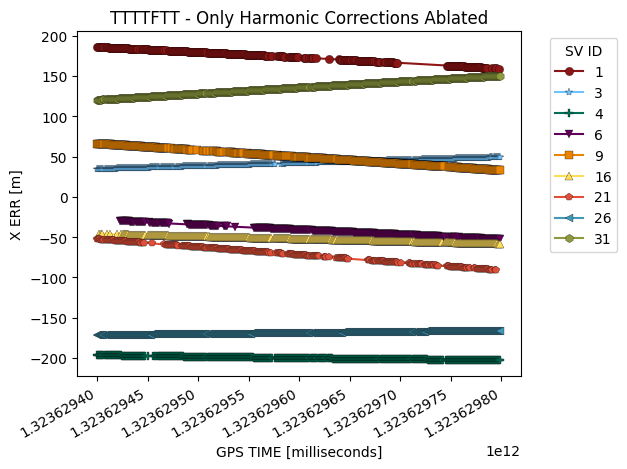

In [42]:
trials = {
  "Only Eccentricity Ablated": "FTTTTTT",
  "Only Secular Corrections Ablated": "TTTFTTT",
  "Only Harmonic Corrections Ablated":"TTTTFTT"
}
def plot_x_error(config_str, title):
  cfg = config_str_to_dict(config_str)
  sv_state_errors = run_problem_1(cfg)
  fig = plt.figure()
  glp.plot_metric(
    sv_state_errors,
    "gps_millis",
    "x_err_m",
    groupby="sv_id",
    title=f"{config_str} - {title}",
    fig=fig,
  )
  plt.show()

for label, cfg in trials.items():
  plot_x_error(cfg, label)

[Provide the requested plots]

### 1.7 Discussion [4 points]

What are your conclusions from the ablation study? Answer the following questions and hypothesize why they were the case. Some will be easier to explain than others.

- Which three variables most impacted the satellite position estimate? Why might this be the case?

- Which three variables most impacted the satellite velocity estimate? Why might this be the case?

- Which three variables most impacted the satellite clock bias estimate? Why might this be the case?

**Hint**: You may find it helpful to reference the plots in lecture 5 in your explanation. Using a first principles analysis can also help (e.g., looking the effect of eccentricity or the drift rate of certain variables).

***ANSWER***

[Answer the questions above. Provide quantitative and qualitative arguments. It is not enough to mention the magnitude of the error without explaining the source.]

For the position and velocity, it was no eccentricity, no secular corrections, and no harmonic corrections. Since the eccentricity directly affects the altitude of the satellite at various points around the orbit, and secular and harmonic corrections affect other, non-negligable sources of GPS error. Therefore, the position error (exhibited in the X direction) is understandably affected very highly by these ablations.

The same ablations were responsible for velocity estimate errors. For higher eccentricity, the satellite will travel at different speeds at different points in its orbit, so this would contribute directly to an error in velocity estimation over time. It also makes sense that this is the ablation that afffects the velocity error the most. For secular and harmonic ablations, since those have to do with the environment, they are slightly less impactful, but still contribute.

Understandably, the clock drift rate and relativistic correction were the variables that affected the time error the most. For the clock drift rate, that affects the bias becuase the clock bias must constantly be corrected in order for the pseudorange and timing measurements to be correct. For relativistic, the satellite velocity is enough to introduce relativistic effects, so not accounting for those introduces some error. Finally, assuming no eccentricity changes the velocities of the satellites at various points in their orbits, which aligns with the errors in position and velocity as well.